In [1]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cd /content/drive/MyDrive/Deep Learning for Computer Vision/6.Object Detection-20251024T084237Z-1-001/Yolov8-12

/content/drive/MyDrive/Deep Learning for Computer Vision/6.Object Detection-20251024T084237Z-1-001/Yolov8-12


In [2]:
ls

drive/  sample_data/


In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="nOGUiSTbKGxLtUpsmE9d")
project = rf.workspace("roboflow-100").project("brain-tumor-m2pbp")
version = project.version(2)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to brain-tumor-2 in yolov8:: 100%|██████████| 19812/19812 [00:01<00:00, 11640.14it/s]


# Yaml File

In [4]:
# Define a function to write text to a file
def write_text_to_file(text, file_path):
    with open(file_path, 'w') as file:
        file.write(text)


text="""
names:
- Benign
- Malignant

nc: 2


test: /content/brain-tumor-2/test/images
train: /content/brain-tumor-2/train/images
val: /content/brain-tumor-2/valid/images

"""

write_text_to_file(text, "data.yaml")

# Model Yolo

In [5]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.5/112.6 GB disk)


| **YOLOv8**   | **YOLOv9**   | **YOLOv10**    | **YOLOv11**   | **YOLOv12**   |
|:------------:|:------------:|:--------------:|:-------------:|:-------------:|
| yolov8n.pt   | yolov9t.pt   | yolov10n.pt    | yolo11n.pt    | yolo12n.pt    |
| yolov8s.pt   | yolov9s.pt   | yolov10s.pt    | yolo11s.pt    | yolo12s.pt    |
| yolov8m.pt   | yolov9m.pt   | yolov10m.pt    | yolo11m.pt    | yolo12m.pt    |
| yolov8l.pt   | yolov9c.pt   | yolov10l.pt    | yolo11l.pt    | yolo12l.pt    |
| yolov8x.pt   | yolov9e.pt   | yolov10x.pt    | yolo11x.pt    | yolo12x.pt    |


In [6]:
# Train YOLOv8n on Cancer for 100 epochs
#!yolo task= detect mode= train data=brain-tumor-2/data.yaml model=yolov8n.pt epochs=5 imgsz=640 batch=16

from ultralytics import YOLO
## Load a COCO-pretrained YOLO12n model
model = YOLO("yolov8n.pt")

## Train the model on the COCO8 example dataset for 100 epochs
results = model.train(data="/content/brain-tumor-2/data.yaml", epochs=5, imgsz=640,batch=16)

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/brain-tumor-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pos

In [ ]:
from IPython.display import Image, display

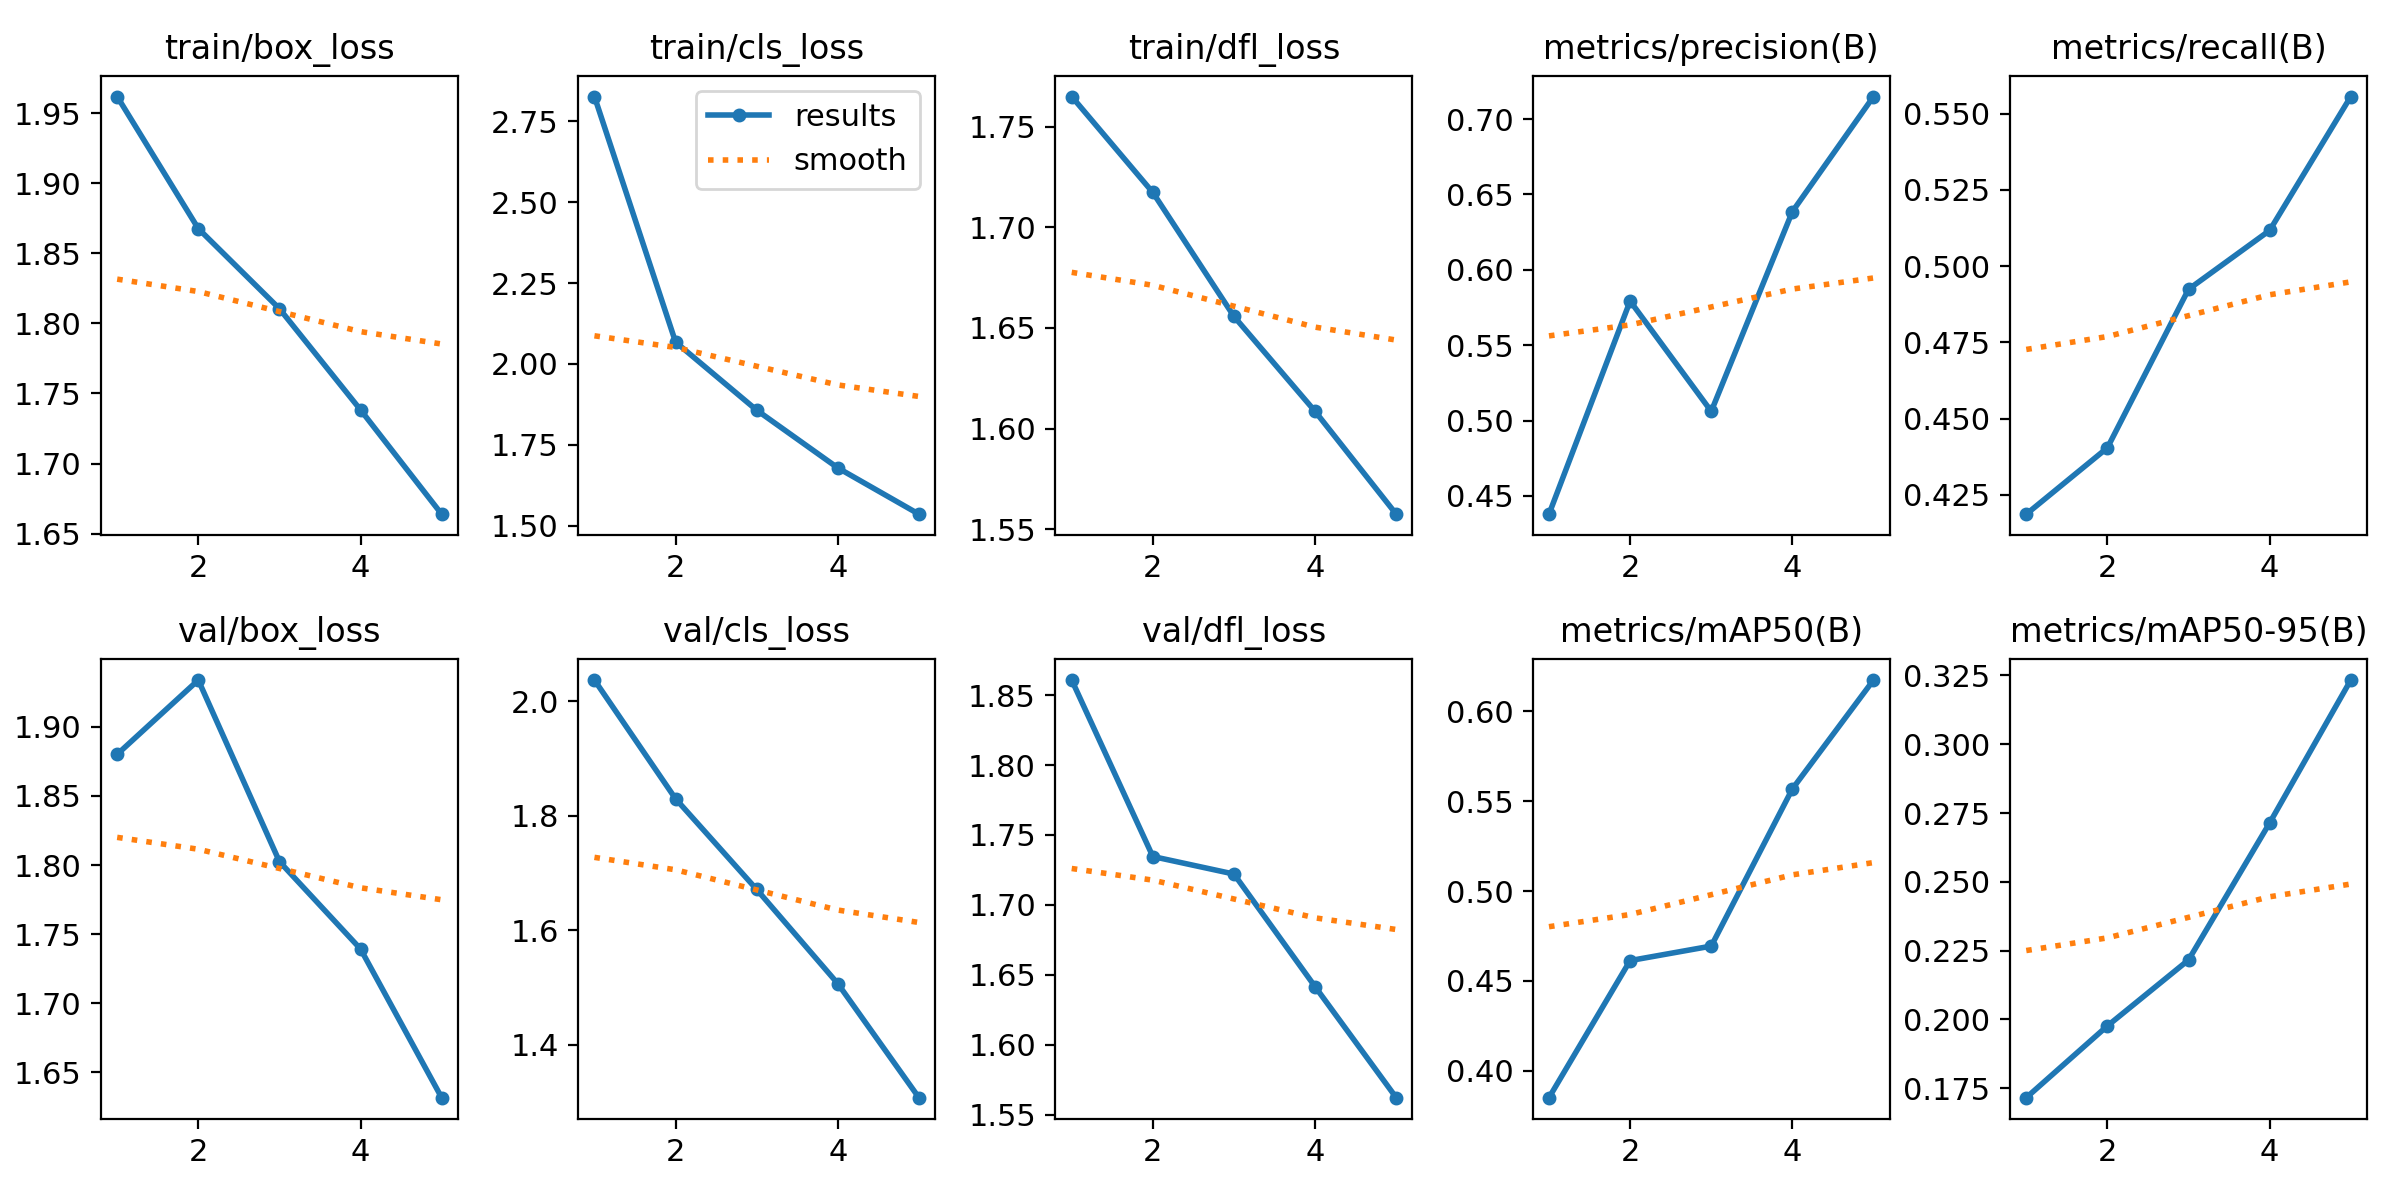

In [ ]:
display(Image(filename=f"runs/detect/train3/results.png", width=1000))

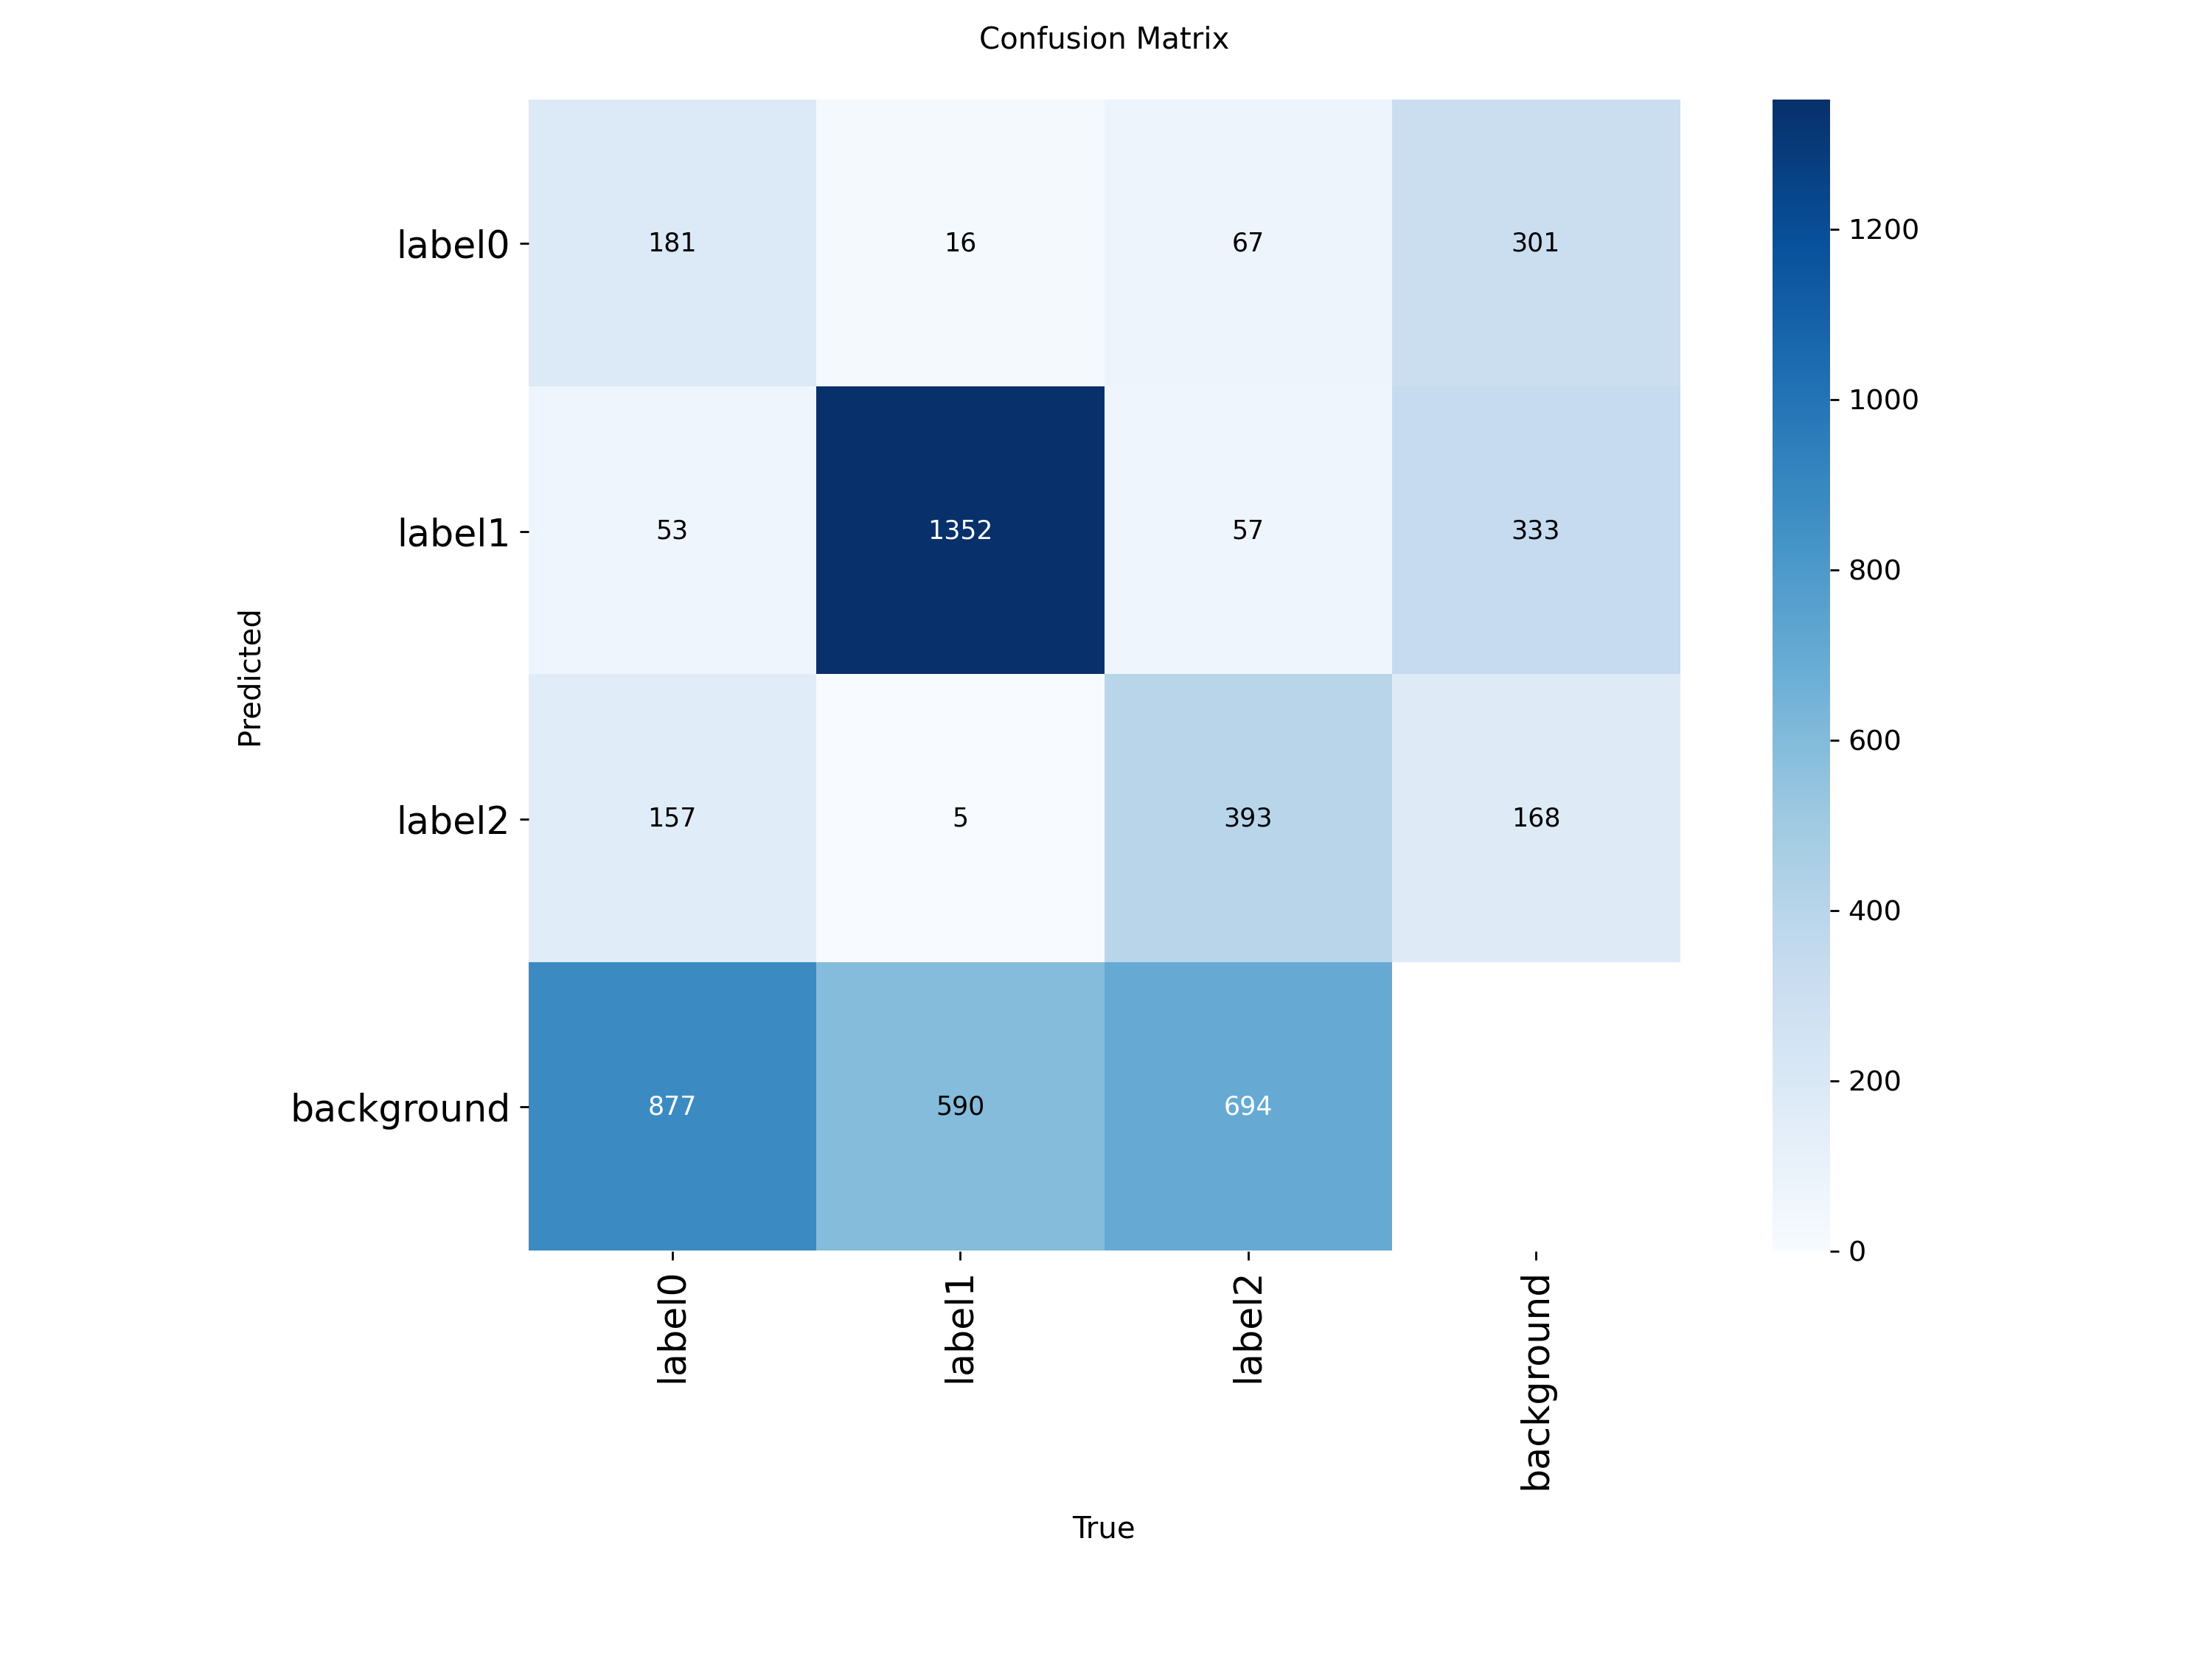

In [ ]:
display(Image(filename=f"runs/detect/train3/confusion_matrix.png", width=1000))

In [ ]:
!yolo task=detect mode=val model=runs/detect/train3/weights/best.pt imgsz=640 conf=0.5 \
data=/data.yaml

from ultralytics import YOLO

# Load a model
model = YOLO("runs/detect/train3/weights/best.pt")  # load a custom model

## Validate the model
metrics = model.val()  # no arguments needed, dataset and settings remembered
metrics.box.map  # map50-95
metrics.box.map50  # map50
metrics.box.map75  # map75
metrics.box.maps  # a list contains map50-95 of each category

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 6.3 GFLOPs
Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/__init__.py", line 985, in entrypoint
    getattr(model, mode)(**overrides)  # default args from model
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 611, in val
    validator(model=self.model)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py", line 120, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/validator.py", line 175, in __call__
    self.data = check_det_dataset(self.args.data)
                ^^^^^^^^^^^^^^^^^^^^

array([    0.21473,     0.45007,     0.30421])

In [ ]:
!yolo task=detect mode=predict model=runs/detect/train3/weights/best.pt imgsz=640 conf=0.5 \
source=brain-tumor-2/test/images

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 6.3 GFLOPs

image 1/990 /content/drive/MyDrive/Deep Learning for Computer Vision/6.Object Detection-20251024T084237Z-1-001/Yolov8-12/brain-tumor-2/test/images/volume_100_slice_105_jpg.rf.76d5a46d0268b812fb2d17702d2c68a2.jpg: 640x640 1 label1, 15.2ms
image 2/990 /content/drive/MyDrive/Deep Learning for Computer Vision/6.Object Detection-20251024T084237Z-1-001/Yolov8-12/brain-tumor-2/test/images/volume_100_slice_47_jpg.rf.1251a28a7dc734c97b852a8a7855d5ff.jpg: 640x640 (no detections), 13.4ms
image 3/990 /content/drive/MyDrive/Deep Learning for Computer Vision/6.Object Detection-20251024T084237Z-1-001/Yolov8-12/brain-tumor-2/test/images/volume_100_slice_48_jpg.rf.99cfad0e43aa2ff320e0e943d56d0d5d.jpg: 640x640 (no detections), 12.9ms
image 4/990 /content/drive/MyDrive/Deep Learning for Computer Vision/6.Object Detection-20251024T084237Z-1

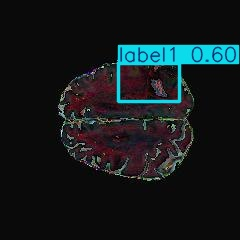

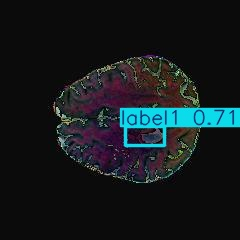

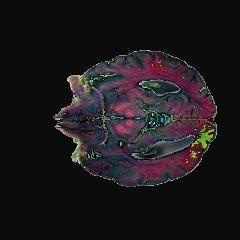

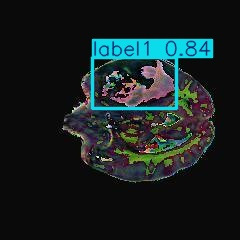

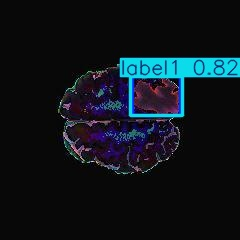

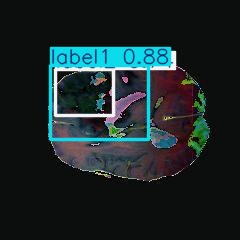

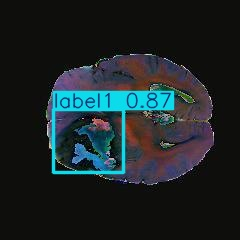

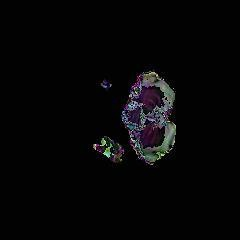

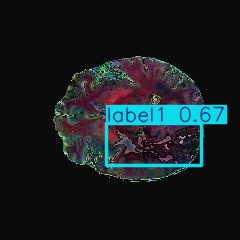

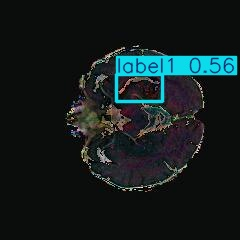

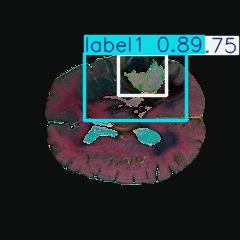

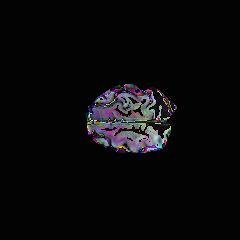

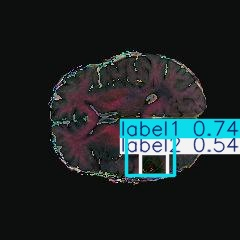

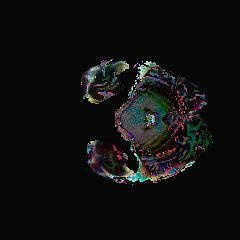

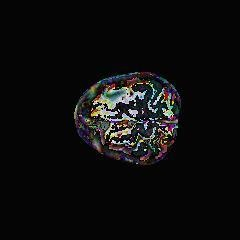

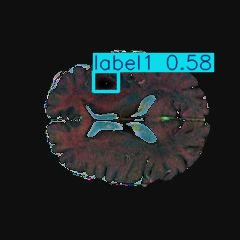

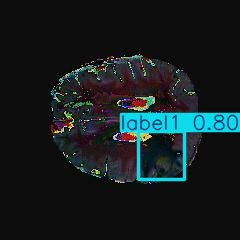

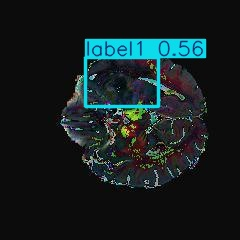

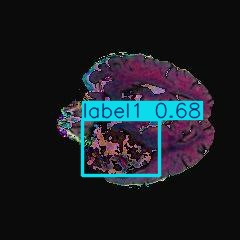

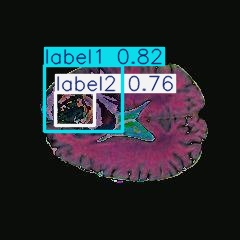

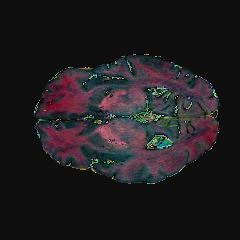

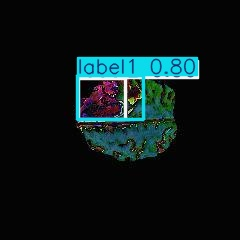

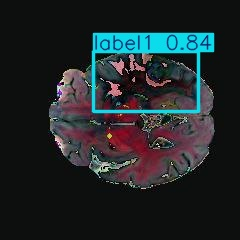

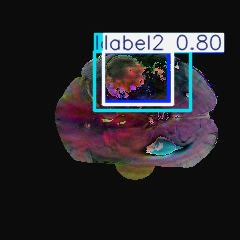

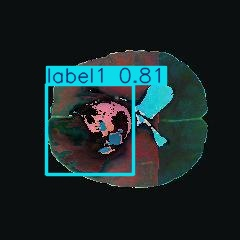

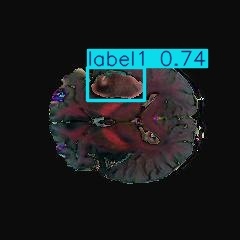

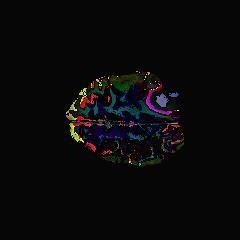

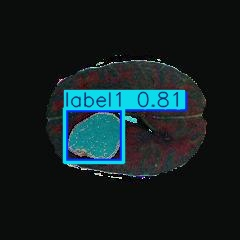

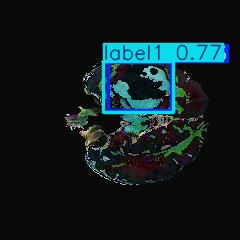

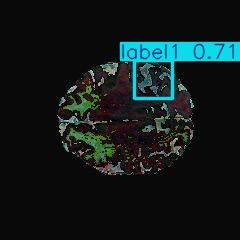

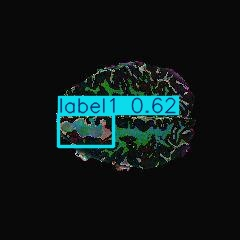

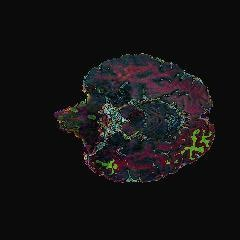

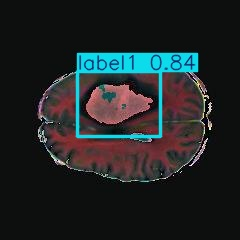

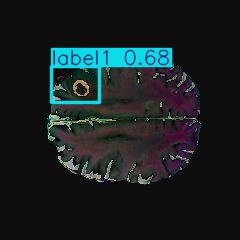

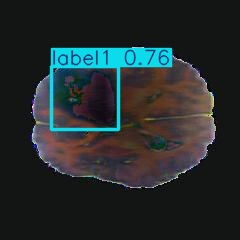

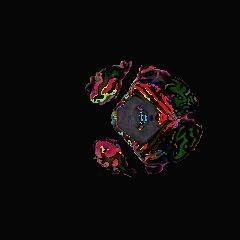

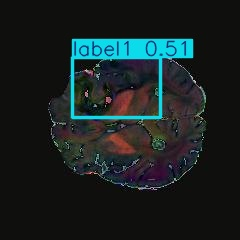

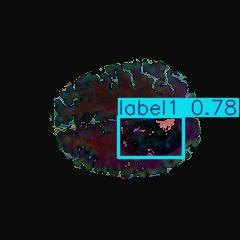

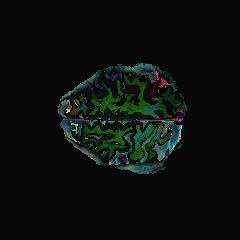

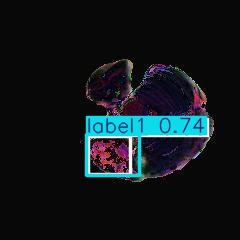

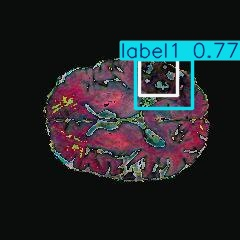

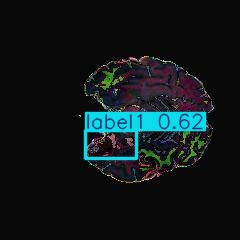

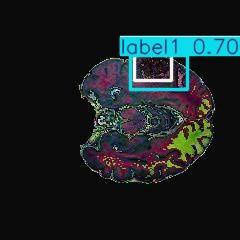

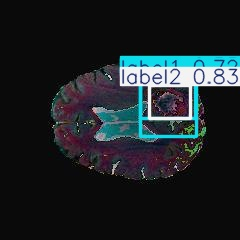

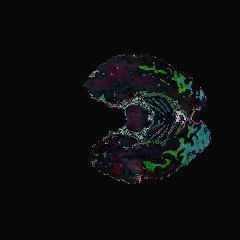

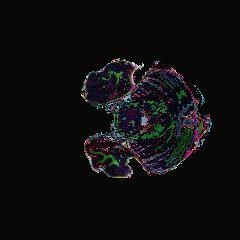

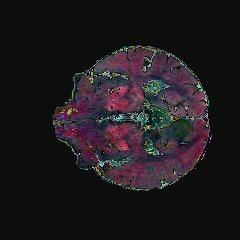

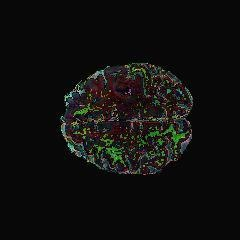

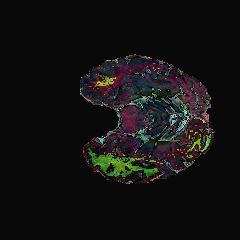

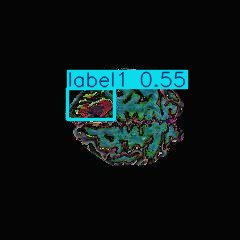

In [ ]:
# Display inference on ALL test images
import glob
from IPython.display import Image, display
i = 0
for imageName in glob.glob("runs/detect/predict/*.jpg"): #assuming JPG
    if i %20 == 0 :
        print("\n")
        display(Image(filename=imageName))
    i = i +1



In [ ]:
!pip install supervision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.4/212.4 kB 20.5 MB/s eta 0:00:00


Streaming output truncated to the last 5000 lines.

0: 640x640 1 label1, 22.6ms
Speed: 3.7ms preprocess, 22.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 label1, 13.8ms
Speed: 3.0ms preprocess, 13.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 label0, 2 label1s, 1 label2, 16.2ms
Speed: 3.3ms preprocess, 16.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 label0, 1 label1, 1 label2, 17.8ms
Speed: 3.3ms preprocess, 17.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 label0, 1 label1, 1 label2, 12.7ms
Speed: 4.0ms preprocess, 12.7ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 13.0ms
Speed: 3.5ms preprocess, 13.0ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 13.3ms
Speed: 3.4ms preprocess, 13.3ms inference, 0.5ms postprocess per image at shape (1, 3, 64

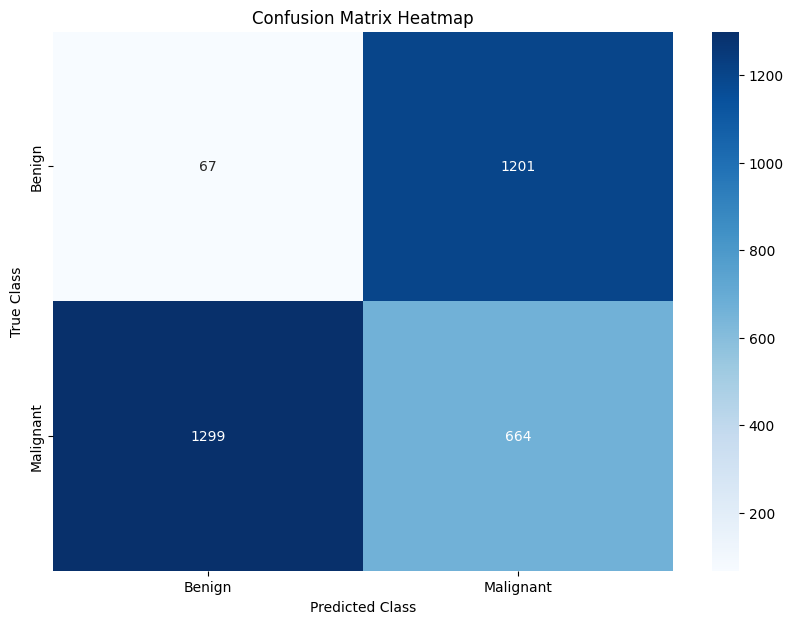

Normalized Confusion Matrix:
[[   0.052839     0.94716]
 [    0.66174     0.33826]]


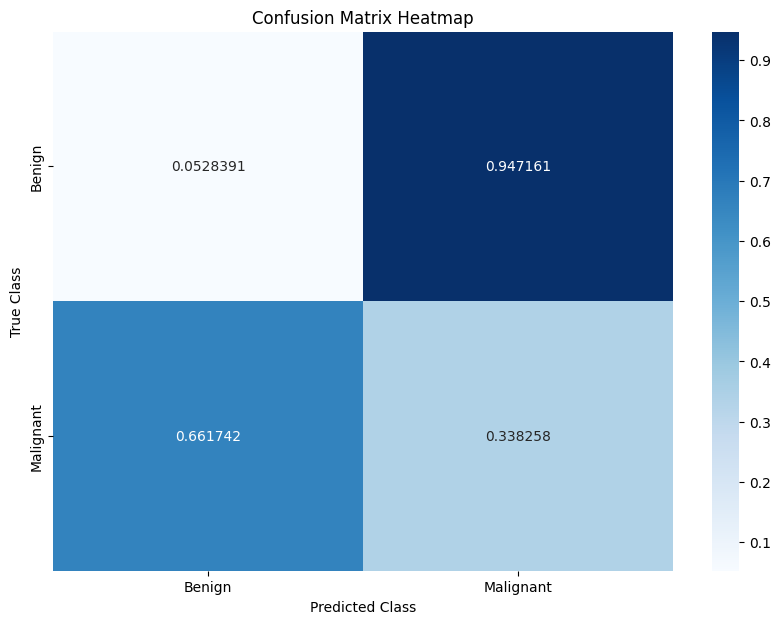

In [ ]:
import numpy as np
import supervision as sv
import torch
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

%matplotlib inline

# Load YOLOv8 model
model = YOLO('runs/detect/train3/weights/best.pt')

# Define the root dataset path (must contain 'images' and 'labels' folders)
dataset_root = 'brain-tumor-2/valid/'

# Create a detection dataset from YOLO format
dataset = sv.DetectionDataset.from_yolo(
    images_directory_path=dataset_root + "images",
    annotations_directory_path=dataset_root + "labels",
    data_yaml_path='data.yaml'
)

def callback(image: np.ndarray) -> sv.Detections:
    # Run inference
    results = model(image)

    # Extract the detections (assumes results[0] contains the necessary data)
    detections = results[0]  # Get the first result

    # Extract the bounding boxes, class IDs, and confidence scores
    boxes = detections.boxes.xyxy.cpu().numpy()  # Bounding boxes in (x1, y1, x2, y2) format
    class_ids = detections.boxes.cls.cpu().numpy()  # Class IDs
    scores = detections.boxes.conf.cpu().numpy()  # Confidence scores

    # Create sv.Detections object
    detections_sv = sv.Detections(
        xyxy=boxes,  # Convert to numpy array
        confidence=scores,
        class_id=class_ids
    )

    # Optionally filter out background (class_id == 0)
    detections_sv = detections_sv[detections_sv.class_id != 0]

    return detections_sv  # Return sv.Detections object

# Function to plot the confusion matrix
def plot_confusion_matrix(conf_matrix, class_names):
    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.title("Confusion Matrix Heatmap")
    plt.show()

# Benchmark the confusion matrix (background class is already ignored)
confusion_matrix = sv.ConfusionMatrix.benchmark(
    dataset=dataset,
    callback=callback
)

# Print class information (without background)
print("Classes (without background):")
class_names = dataset.classes
print(class_names)

# Adjust confusion matrix to ignore background
confusion_matrix = confusion_matrix.matrix[:-1, 1:]  # Assuming the last row is background
# Print the confusion matrix
print("Confusion Matrix (without background):")
print(confusion_matrix)

# Plot the raw confusion matrix
plot_confusion_matrix(confusion_matrix, class_names)

# Normalize the confusion matrix
def normalize_confusion_matrix(matrix):
    return matrix.astype('float') / matrix.sum(axis=1)[:, np.newaxis]

# Optionally normalize the confusion matrix
normalized_matrix = normalize_confusion_matrix(confusion_matrix)
print("Normalized Confusion Matrix:")
print(normalized_matrix)

# Plot the normalized confusion matrix
plot_confusion_matrix(normalized_matrix, class_names)
